# Building Grid

I am still doing this on a grid, but now with a better parameter choice. I have trimmed the number of print statements from the grid calculation.

In [9]:
#--LIBRARIES--------

import eelib
from eelib import pi

import numpy as np
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression

#plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization

Added $k_0$ variation. Needs to later be tested with full variation. And for $\mu = 0$.

In [14]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-7

#n_dk = 5
n_m  = 5
n_g  = 10
n_k0 = 8
#n_a = 1
n_b  = 5
#n_r  = 5


b_r  = (0.03, 1.0) # B here is B*R, since varying R will alter k, which I don't want
dk_r = (0.2, 0.8)
mu_r = (-8, -5.8) #1.0e-8 to 1.0e-5
k0_r = (0.5 * eelib.kFAu, 2 * eelib.kFAu)

num_l = [n_m, n_b, n_k0, n_g]

#k0_r #later ....

# These two will not be varied, since they can be accomodated by a rescaling.
#a_r = 0.5
#r_r  = (0.5, 1.1)

pr = 200
n = 20

In [15]:
#--CODE--

#make loop, grid, or system
gridl = eelib.grid_fast_osc(R, B, dk, mu)

gridl.makeGridPoints(mu=mu_r,B=b_r, k0=k0_r, num = num_l)
gridl.gridFastOsc()

Begin grid build:  0.0
Number of periods to calculate: 20000
mu: 0, dk: 0, Time: 0.011960744857788086
mu: 1, dk: 0, Time: 1508.5686881542206
mu: 2, dk: 0, Time: 3097.47913146019
mu: 3, dk: 0, Time: 4526.02939581871
mu: 4, dk: 0, Time: 5979.558374404907
Done grid build:  7528.510821342468


In [16]:
# since this takes a while to run and is used for a while, it is best to save a copy of the data
file = open('grid005', 'ab')
pickle.dump(gridl, file)
file.close()

In [ ]:
#loading script; be careful of python version
#file = open('grid001', 'rb')    
#gridl = pickle.load(file)
#file.close()

# Defining variables for analysis

In [17]:
# Pull the grids of values from our object

# independent variables
B_g = gridl.mfs  # B (for B * R)
k0_g = gridl.ew    # k
mu_g = gridl.nls   # mu
#amp = gridl.amp
dgrid = gridl.d0_grid

# dependent variables
fot = gridl.fast_osc_t[:,0,:,0,0,:,:,:]

In [18]:
dfot = np.copy(fot)
for ii, kk in enumerate(k0_g):
    dfot[:,:,ii,:,:] = fot[:,:,ii,:,:] - pi /(kk+dk/1e-6/2.0)

In [19]:
dgridk = np.zeros((n_k0,n_g,n_g), dtype=complex)
for ii, kk in enumerate(k0_g):
    dgridk[ii] = dgrid/(kk+dk/1e-6/2.0)

In [41]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_k0*n_b*n_g**2, n_k0*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ib in range(n_b):
        for ik in range(n_k0):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[2]+ib*sz[1]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 2] = k0_g[ik]
                    npaf[ind, 1] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (k0_g[ik] + dk/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (k0_g[ik] + dk/R /2.0)
                    npaf[ind, 5] = fot[imu, ib, ik, idr, idi]-(pi / (k0_g[ik] + dk/R /2.0))

20000


In [22]:
np.shape(fot)

(5, 5, 8, 10, 10)

In [42]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "B", "k_0", "D re", "D im", "T fast"])

# and to show it
dfa.head()

,mu,B,k_0,D re,D im,T fast
0,1.000000e-08,0.03,6.000000e+09,-2.761620,-2.76162,2.499135e-14
1,1.000000e-08,0.03,6.000000e+09,-2.526461,-2.76162,2.126958e-14
2,1.000000e-08,0.03,6.000000e+09,-2.023802,-2.76162,1.448675e-14
3,1.000000e-08,0.03,6.000000e+09,-1.306865,-2.76162,7.426259e-15
4,1.000000e-08,0.03,6.000000e+09,-0.451559,-2.76162,2.819256e-15


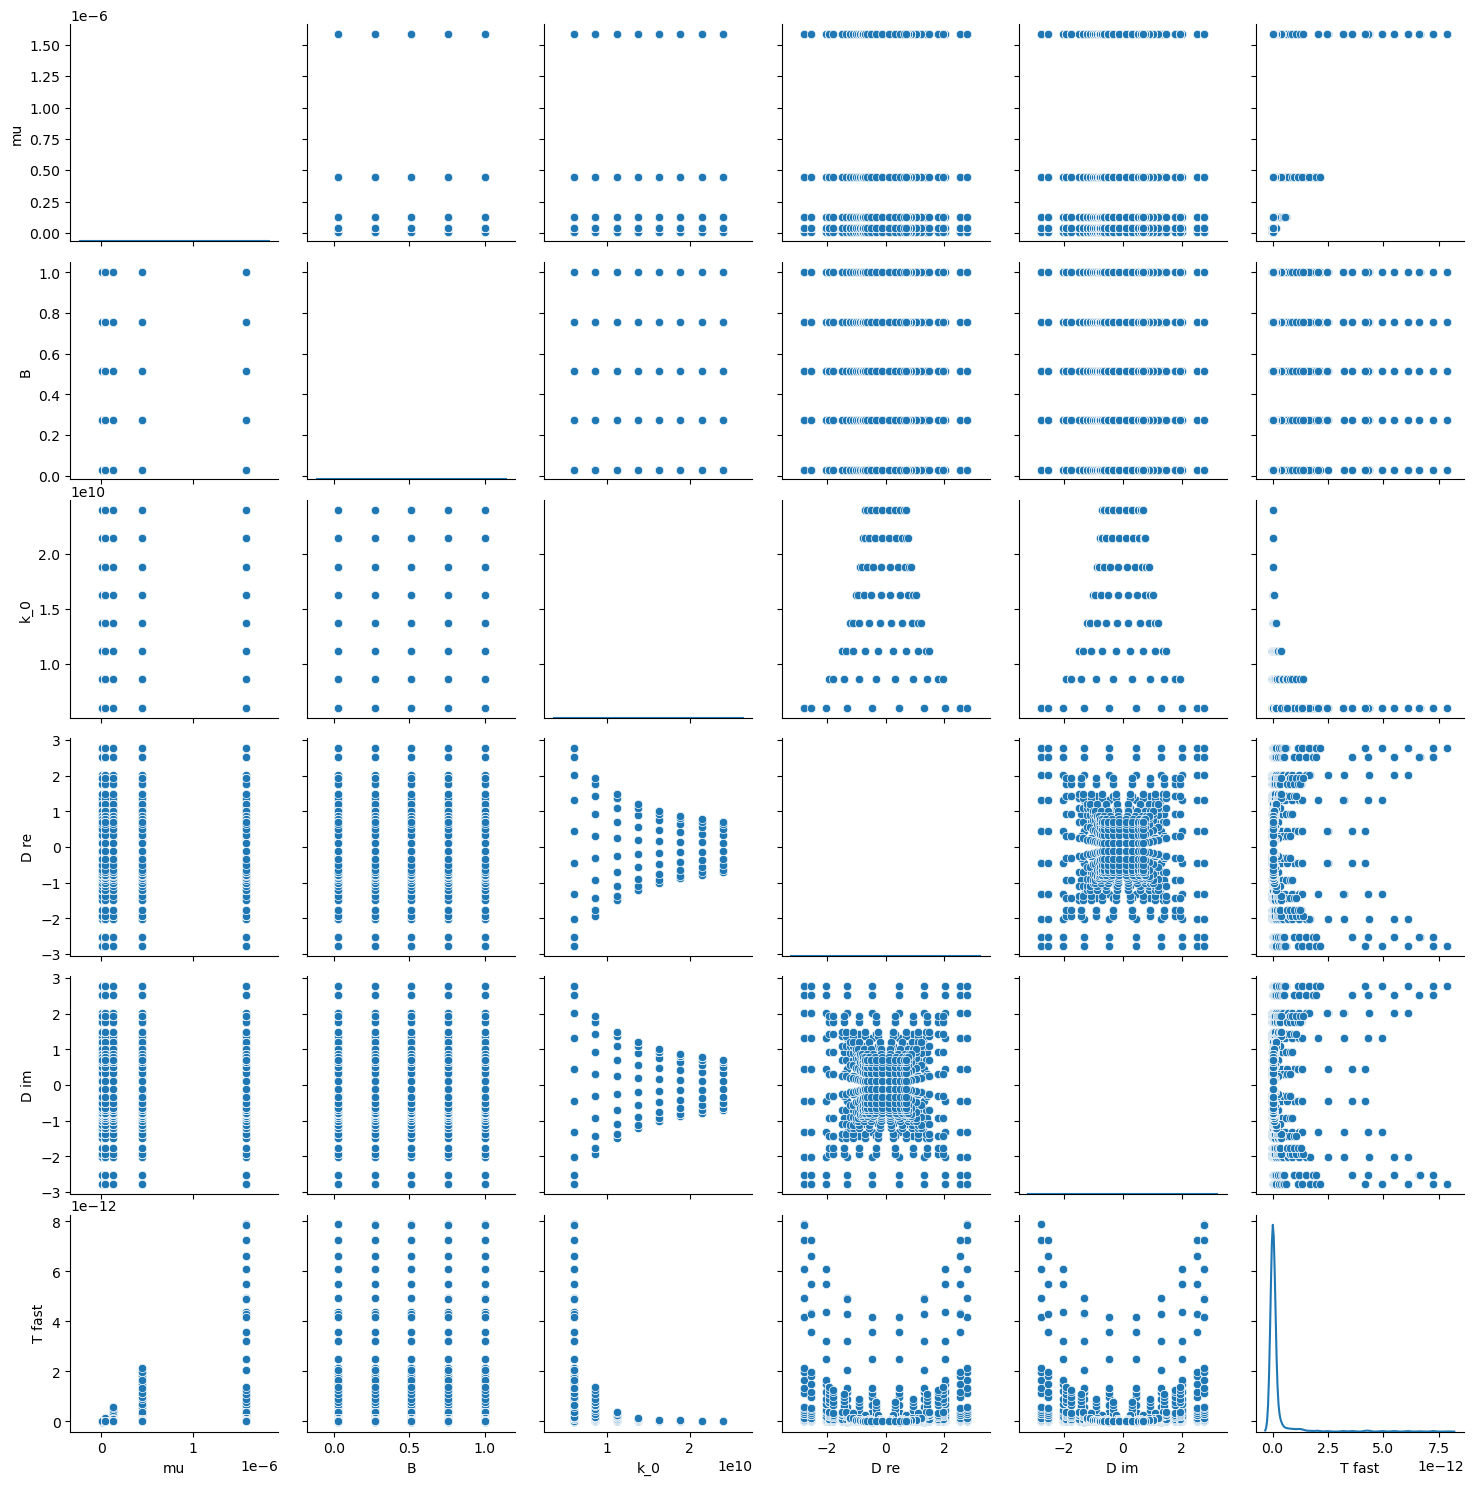

In [26]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

It looks good here. Not like before, but it should be correct. ... I want to start with the old model. 

# Compare to Old Model

In [27]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_k0*n_b*n_g**2, n_k0*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ib in range(n_b):
        for ik in range(n_k0):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[2]+ib*sz[1]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 2] = k0_g[ik]
                    npaf[ind, 1] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (k0_g[ik] + dk/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (k0_g[ik] + dk/R /2.0)
                    npaf[ind, 5] = fot[imu, ib, ik, idr, idi]- eelib.pred_fast_t(dphi0 = dgrid[idr, idi], 
                                                                                 mu= mu_g[imu], dk = dk, B=B_g[ib], R = R, k0=k0_g[ik])

20000


In [28]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "B", "k_0", "D re", "D im", "T fast"])

# and to show it
dfa

,mu,B,k_0,D re,D im,T fast
0,1.000000e-08,0.03,6.000000e+09,-2.761620,-2.761620,3.754743e-14
1,1.000000e-08,0.03,6.000000e+09,-2.526461,-2.761620,3.438328e-14
2,1.000000e-08,0.03,6.000000e+09,-2.023802,-2.761620,2.862604e-14
3,1.000000e-08,0.03,6.000000e+09,-1.306865,-2.761620,2.263627e-14
4,1.000000e-08,0.03,6.000000e+09,-0.451559,-2.761620,1.870364e-14
...,...,...,...,...,...,...
19995,1.584893e-06,1.00,2.400000e+10,0.112890,0.690405,-7.556276e-14
19996,1.584893e-06,1.00,2.400000e+10,0.326716,0.690405,-8.036170e-14
19997,1.584893e-06,1.00,2.400000e+10,0.505951,0.690405,-8.802000e-14
19998,1.584893e-06,1.00,2.400000e+10,0.631615,0.690405,-9.532023e-14


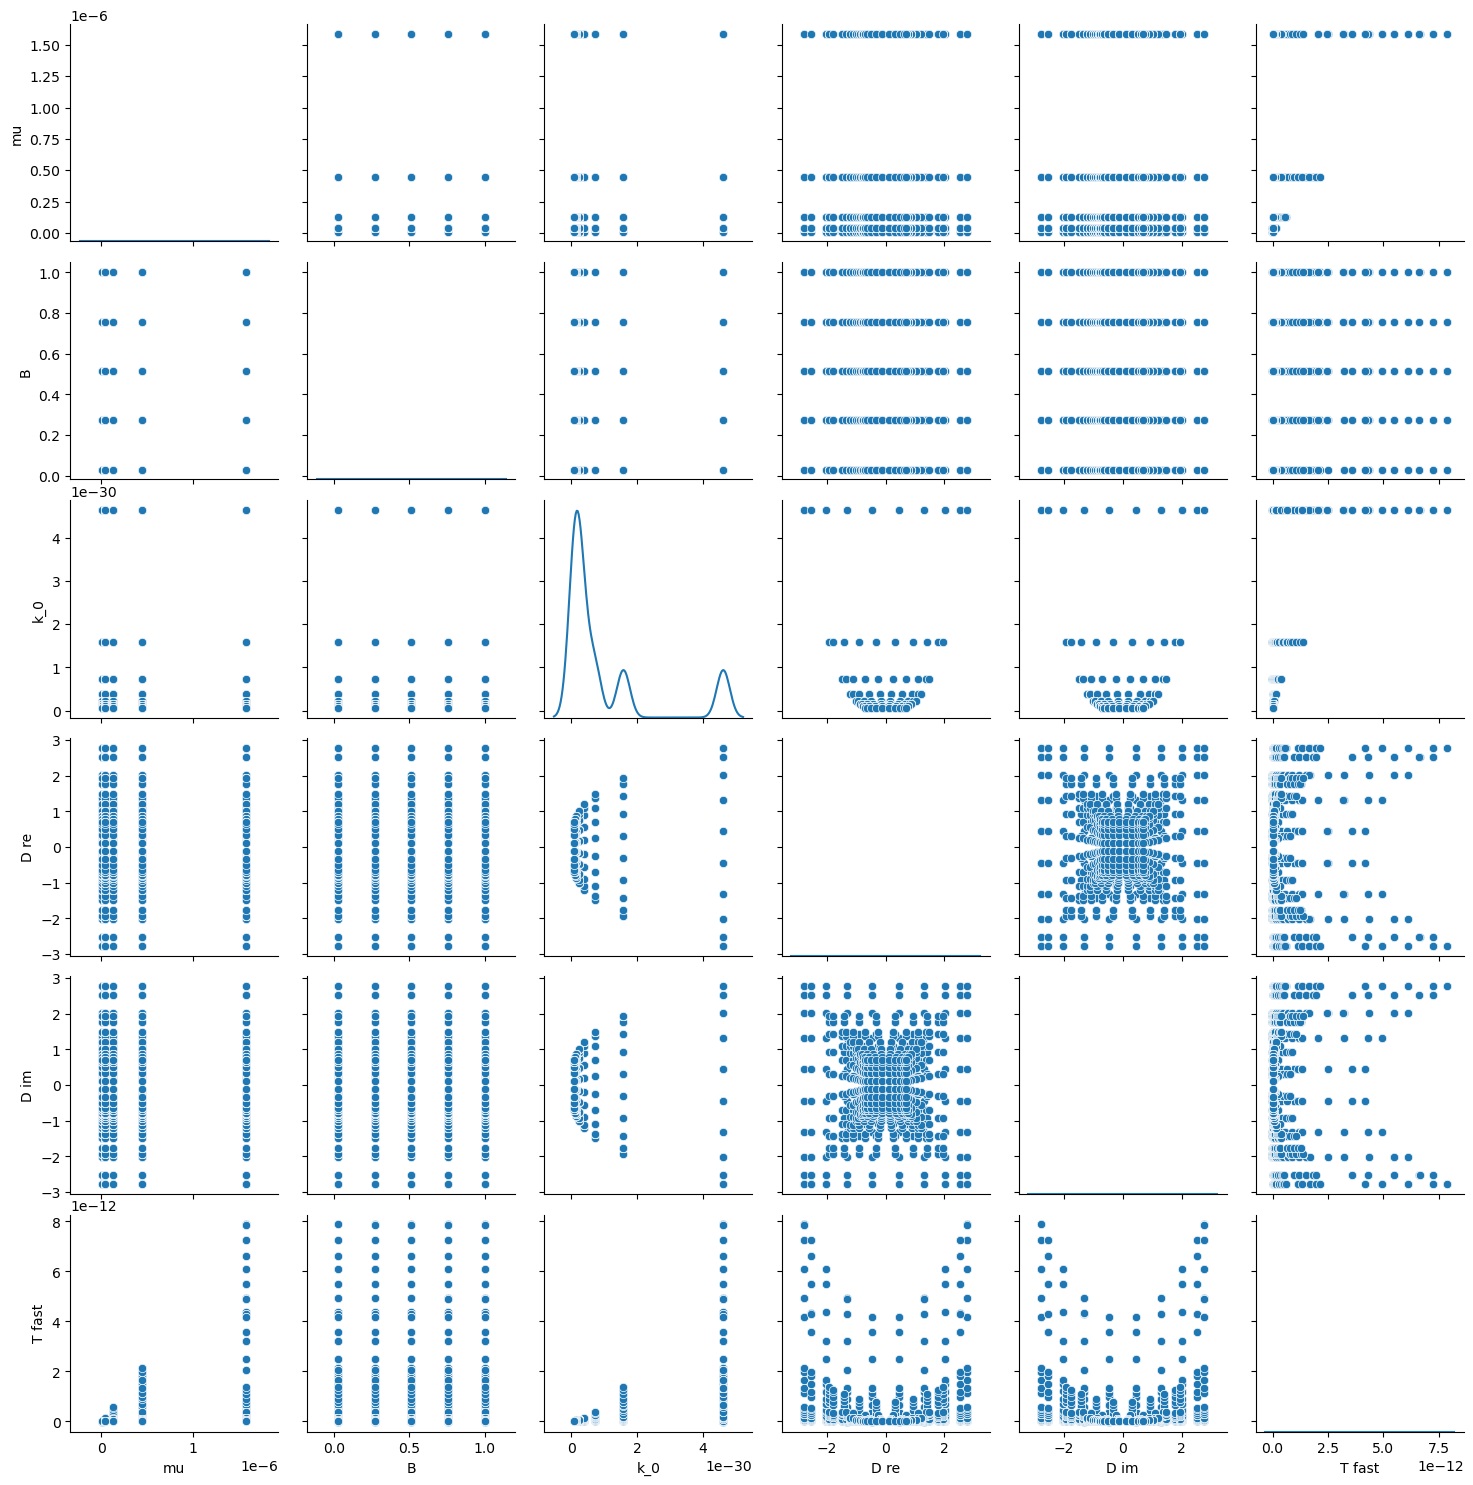

In [51]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

As expected, I need to redo everything for $k$ dependence. It look to between k^-3 and k^-4. I am going to try k^-1, and recalculate the model. t is dependent on k^-1, so I think the correction also has a k^-1 term. Then the derivative correction also has a k^-2 term, so it should be a k^-1 + b k^-3. If this is true, then the constants have an inverse relationship with k^-1, but the magnetic field and derivative terms have an additional scaling based on k.

In [54]:
cons = eelib.k_M_models.const_dic_001
cons

{'mA2': 3.675494115574291e-08,
 'mDIM': -6.179621225636901e-11,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17}

In [60]:
for dd in cons:
    print(cons[dd]*eelib.kFAu)

441.0592938689149
-0.7415545470764281
440.9040533316487
440.92380652255906
102266.68300116419
246673.37710257643
352303.1705416137
191784.85411316005
190926.93497188206
381883.043416857
-6.83683757806049e-06
-3.3141913676936506e-06
9.71521371775632e-07
1.1031578181823056e-06


In [44]:
npaf[:, 2] = 1/ npaf[:, 2] 

In [50]:
npaf[:, 2] = np.power(npaf[:, 2], 3/4)

# $\mu$ linear regression fitting

Linear regression will proceed as before. I will fit $\mu^2$, $\mu$, and the intercept terms. $\mu$ should be primary, while $\mu^2$ and the intercept are the corrections. Corrections are important due to rapid oscillation.

I believe that the intercept term is due to a constant underestimating of the period, which exists even within the case without ee interaction. This error is small, but adds up over oscillations, and therefore needs to be properly modelled in order to match the two sides. Fortunately, we have the exact solution without ee interaction to aid in modelling. I also know that drop in amplitude for the ee interaction case is identical to that without, so the issue should be solvable.

Let us start with plotting. We need to change the variables in all of the code below. 

In [124]:
mu_g = mu_g / 1e-6
k0_g = k0_g / 1.5e10
print(np.average(B_g), np.average(mu_g), np.average(k0_g), np.average(dgrid))

0.515 0.44059013294297034 1.0 (-1.52587890625e-07-1.220703125e-06j)


In [162]:
k0_g = k0_g * 1.5e10 + dk/1e-6/2.0

In [163]:
k0_g = k0_g / 1.5e10

In [126]:
np.average(np.abs(dgridk))

1.3213869150341244

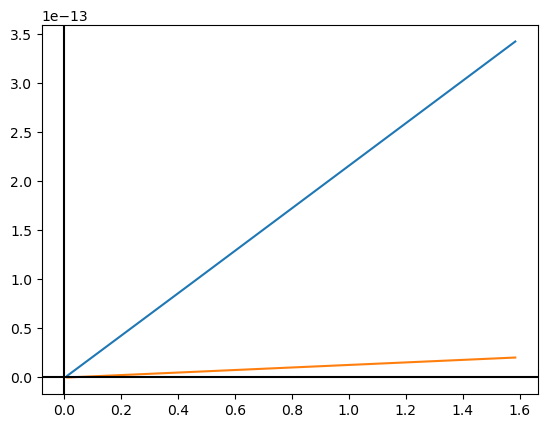

In [127]:
# for easy changing which two plots to use.

mui = []
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(mui), len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(mu_g, dfot[:, bi[i],ki[i],d1i[i],d2i[i]])
plt.axline((0,0), (1e-15,0), color='k')
plt.axline((0,0), (0,1e-15), color='k')
plt.show()

We ideally want the error below $7 \times 10^{-16}$. Note that dk doesn't change this estimate at all.

And now regression.

In [184]:
slope = np.zeros((n_b, n_k0, n_g, n_g, 2))
intercept = np.zeros((n_b, n_k0, n_g, n_g))
r = 1.1    # for finding the minimum r value

for i in range(n_b):
    for j in range(n_k0):
        for k1 in range(n_g):
            for k2 in range(n_g):
                X = np.array([mu_g[:], np.power(mu_g[:],2)]).T
                y = dfot[:,i,j,k1,k2]

                reg = LinearRegression().fit(X, y)

                slope[i,j,k1,k2]=reg.coef_
                intercept[i,j,k1,k2]=reg.intercept_

                r2 = reg.score(X, y)
                r = min(r, r2)

                #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9999973758977865


Not bad. Not as good as before.

In [182]:
np.min(dfot), np.max(dfot)

(-3.535103233308662e-16, 7.906666108987873e-12)

In [185]:
print(np.min(slope[:,:,:,:,0]), np.max(slope[:,:,:,:,0]))
print(np.min(slope[:,:,:,:,1]), np.max(slope[:,:,:,:,1]))
print(np.min(intercept), np.max(intercept))

4.710374326964382e-15 4.777120807187287e-12
-6.774309195625138e-17 1.3396350502078863e-13
-1.539926353513575e-15 -2.1256229571204245e-16


# Visualization

In [131]:
slope_lin = slope[:,:,:,:,0]
slope_quad = slope[:,:,:,:,1]

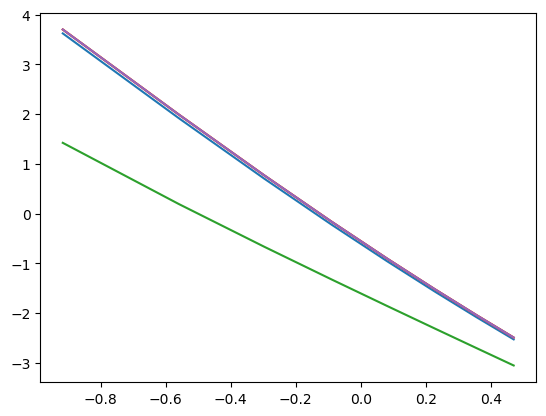

In [197]:
ki  = [2, 6, 4]
bi  = [3, 1, 4, 0, 2]
d1i = [0, 1, 4, 8, 1]
d2i = [2, 8, 4, 8, 1]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.log(k0_g), np.log(slope_lin[bi[i], :,d1i[i],d2i[i]]/1e-13))
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Not linear, but there is an approximate power law here. The slope seems dependent on the derivative term, explaining the problems I was having before. 

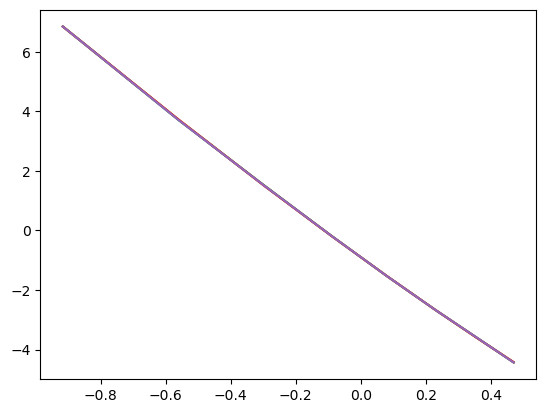

In [194]:
ki  = [2, 6, 4]
bi  = [3, 1, 4, 0, 2]
d1i = [1, 8, 1, 8, 1]
d2i = [1, 8, 1, 8, 1]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.log(k0_g), np.log(slope_quad[bi[i], :,d1i[i],d2i[i]]/1e-16))
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Ok. From what I see here, the quadratic $\mu$ term becomes important at some point here. Nothing is contradicting what I expect from before. It is likely that the $\mu^3$ terms are also more relevant later, explaining the worse fit. I can start with the $\mu$ split. $\mu$ is unknown, except for the fact that my model assumes weak non-linearity, so if even $\mu^2$ become too relevant, the model is no longer valid. I could adjust my variables based on this, or remove the problematic datapoints, where the model begins to leave weak non-linearity. For now I will not.

I think fitting $\mu$, then $k$ is the best approach here. I can fit $\Psi^\prime$ and $B$ later. The main question is what exactly this power law is and how it varies with $\mu$ and $\Psi^\prime$. After that, finding a good fit is not a problem. I think I would like to just start with gold, and if there is time, I can then fit for any $k$. This behavior is interesting, but much more difficult to examine.

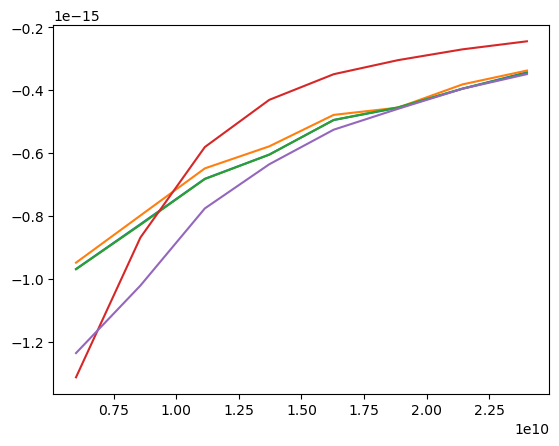

In [ ]:
ki  = [2, 6, 4]
bi  = [3, 1, 4, 0, 2]
d1i = [1, 8, 1, 4, 7]
d2i = [1, 8, 1, 4, 3]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(k0_g, intercept[bi[i], :,d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

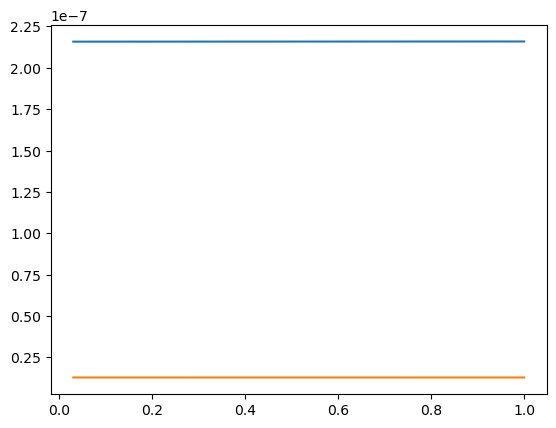

In [74]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(B_g, slope_lin[:, ki[i],d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

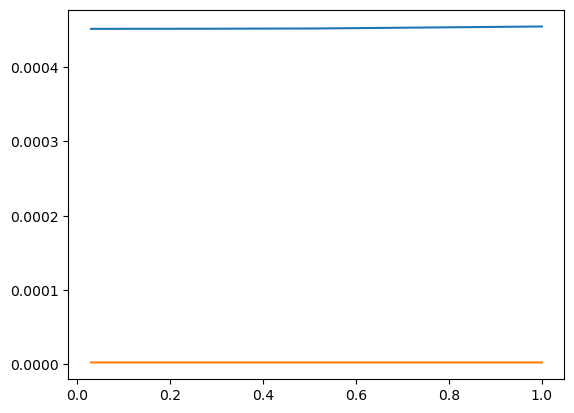

In [75]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(B_g, slope_quad[:, ki[i],d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

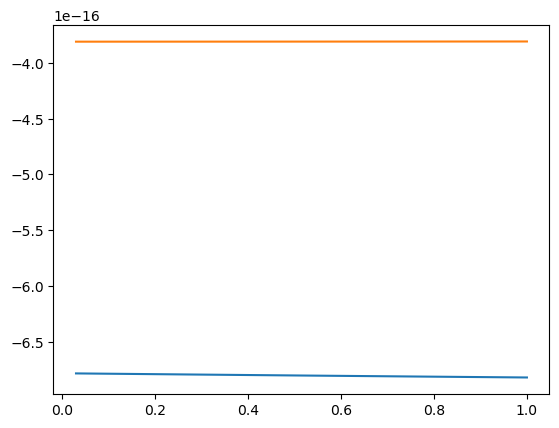

In [76]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(B_g, intercept[:, ki[i],d1i[i],d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

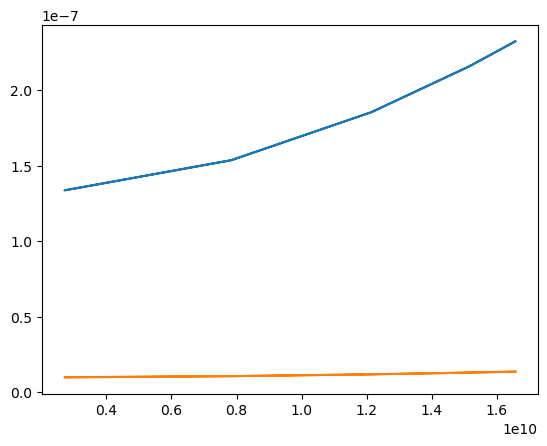

In [78]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.real(dgrid[d1i[i],:])), slope_lin[bi[i], ki[i],d1i[i], :])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

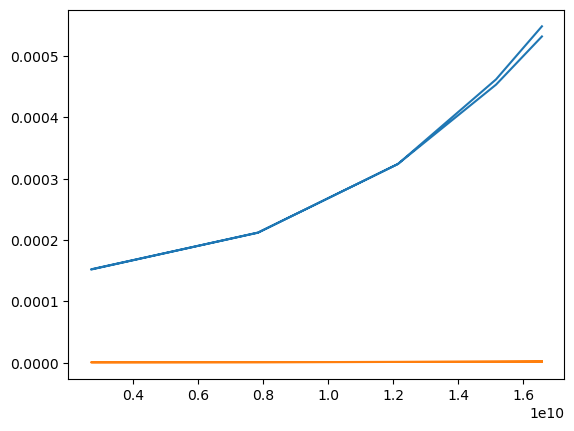

In [106]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 5]
d2i = [1, 5]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.real(dgrid[d1i[i],:])), slope_quad[bi[i],ki[i],d1i[i], :])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

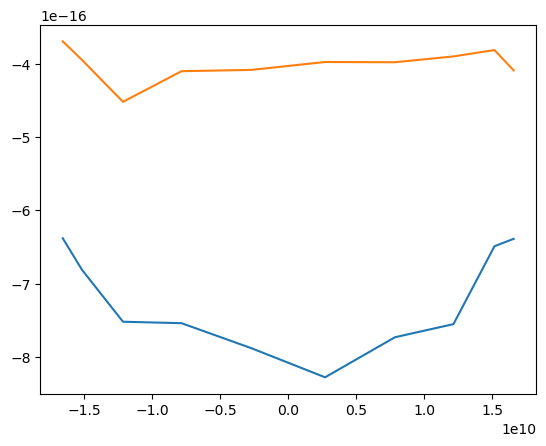

In [80]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.real(dgrid[d1i[i],:]), intercept[bi[i],ki[i],d1i[i], :])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

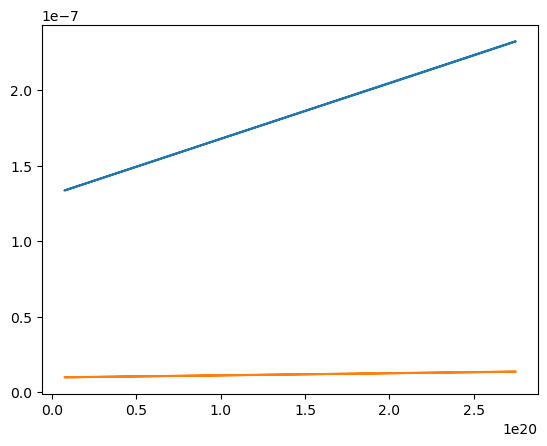

In [81]:
ki  = [2, 6]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.imag(dgrid[:,d2i[i]])**2), slope_lin[bi[i],ki[i],:,d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

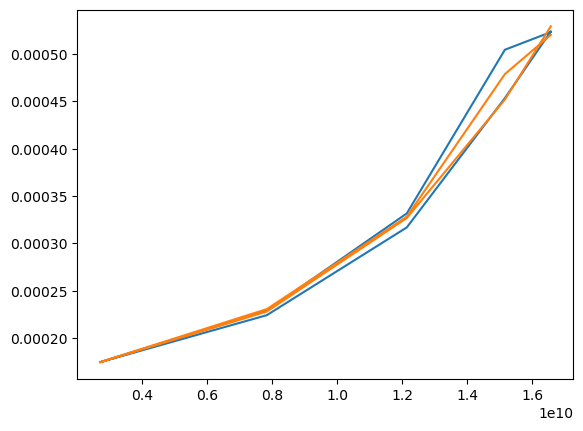

In [88]:
ki  = [2, 2]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(np.imag(dgrid[:,d2i[i]])), slope_quad[bi[i],ki[i],:,d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

Quadratic and quartic terms of derivative.

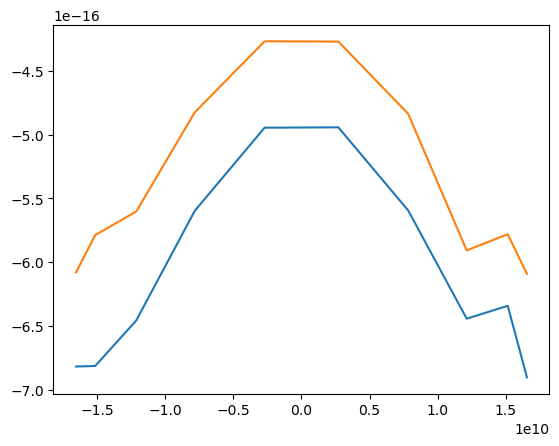

In [87]:
ki  = [2, 3]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.imag(dgrid[:,d2i[i]]), intercept[bi[i],ki[i],:,d2i[i]])
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

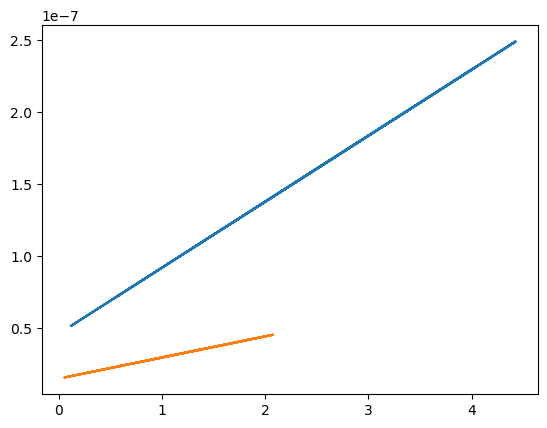

In [86]:
ki  = [2, 4]
bi  = [4, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(dgridk[ki[i]].flatten())**2, slope_lin[bi[i],ki[i]].flatten())
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

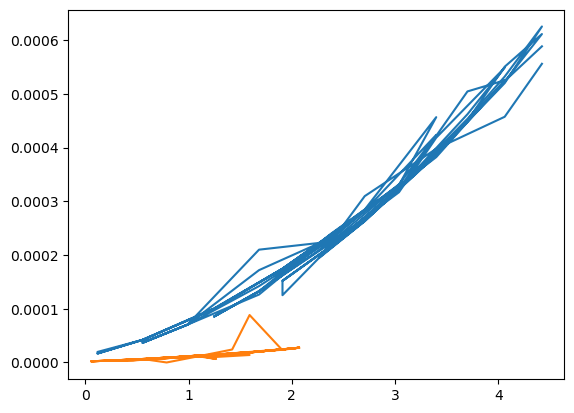

In [85]:
ki  = [2, 4]
bi  = [3, 1]
d1i = [1, 8]
d2i = [1, 8]

ilim = max(len(ki), len(bi), len(d1i), len(d2i))
fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(np.abs(dgridk[ki[i]].flatten())**2, slope_quad[bi[i], ki[i]].flatten())
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

# $\Psi^\prime_0$ Regression

**$\mu$ term**

In [135]:
slope_md = np.zeros((n_b,n_k0,6))
intercept_md = np.zeros((n_b, n_k0))
r = 1.1    # for finding the minimum r value


for ii in range(n_b):
    for jj in range(n_k0):
        X = np.array([np.imag(dgridk[jj].flatten()), np.imag(dgridk[jj].flatten())**2, np.real(dgridk[jj].flatten())**2, 
                      np.real(dgridk[ii].flatten())**4, np.imag(dgridk[ii].flatten())**4, 
                      np.real(dgridk[ii].flatten())**2*np.imag(dgridk[ii].flatten())**2]).T
        y = slope_lin[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_md[ii,jj]=reg.coef_
        intercept_md[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.9998492300549028


In [137]:
print(np.min(slope_md[:,:,0]), np.max(slope_md[:,:,0]))
print(np.min(slope_md[:,:,1]), np.max(slope_md[:,:,1]))
print(np.min(slope_md[:,:,2]), np.max(slope_md[:,:,2]))
print(np.min(slope_md[:,:,3]), np.max(slope_md[:,:,3]))
print(np.min(slope_md[:,:,4]), np.max(slope_md[:,:,4]))
print(np.min(slope_md[:,:,5]), np.max(slope_md[:,:,5]))
print(np.min(intercept_md), np.max(intercept_md))

-9.725505627556407e-16 1.349510289146059e-18
4.588370151428162e-15 2.9411237910396564e-13
4.572638696886461e-15 2.9411340474253386e-13
-1.0651975392130833e-15 3.31107423350994e-17
-1.0983077580695604e-15 7.620406466091427e-17
-2.2966143251217777e-15 1.558824822917142e-17
4.5907843486058674e-15 2.938170028363526e-13


The higher order terms may be relevant, but the main terms here are for $|\Psi_0|^2$ and $|\Psi^\prime_0|^2$ as expected, and they are all very close to each other. Lets look at the correction terms for other orders of $\mu$ now, and get back to this later.

**$\mu^2$ Terms**

In [169]:
slope_m2d = np.zeros((n_b,n_g, n_g, 4))
intercept_m2d = np.zeros((n_b,n_g, n_g))
r = 1.1    # for finding the minimum r value


for ii in range(n_b):
    for jj in range(n_g):
        for kk in range(n_g):
            X = np.array([(k0_g)**-4, (k0_g)**-1, (k0_g)**-2, (k0_g)**-3]).T
            y = slope_quad[ii,:, jj,kk].flatten()

            reg = LinearRegression().fit(X, y)

            slope_m2d[ii,jj, kk]=reg.coef_
            intercept_m2d[ii,jj, kk]=reg.intercept_

            r2 = reg.score(X, y)
            r = min(r, r2)

            #print(ii,jj,r2)

print(r)

0.9998035247271397


If I rescale k0, this works better. I should try this everywhere.

In [170]:
print(np.min(slope_m2d[:,:,:,0]), np.max(slope_m2d[:,:,:,0]))
print(np.min(slope_m2d[:,:,:,1]), np.max(slope_m2d[:,:,:,1]))
print(np.min(slope_m2d[:,:,:,2]), np.max(slope_m2d[:,:,:,2]))
print(np.min(slope_m2d[:,:,:,3]), np.max(slope_m2d[:,:,:,3]))
print(np.min(intercept_m2d), np.max(intercept_m2d))

-9.340793336369046e-17 3.499839348421077e-14
-1.6190945370002992e-13 1.026357550596221e-15
-1.3029704276045376e-15 2.3827597458173324e-13
-1.5087991083277e-13 6.492823435468559e-16
-2.7826886533693984e-16 3.977863290180735e-14


In [142]:
slope_m2d = np.zeros((n_b,n_k0, 7))
intercept_m2d = np.zeros((n_b,n_k0))
r = 1.1    # for finding the minimum r value


for ii in range(n_b):
    for jj in range(n_k0):
        X = np.array([np.imag(dgridk[jj].flatten()), np.real(dgridk[jj].flatten()),
                      np.imag(dgridk[jj].flatten())**2, np.real(dgridk[jj].flatten())**2, 
                      np.real(dgridk[jj].flatten())**4, np.imag(dgridk[jj].flatten())**4, 
                      np.real(dgridk[jj].flatten())**2 *np.imag(dgridk[jj].flatten())**2]).T
        y = slope_quad[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_m2d[ii,jj]=reg.coef_
        intercept_m2d[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii,jj,r2)

print(r)

0 0 0.999981173537018
0 1 0.9997369342187417
0 2 0.985442033583351
0 3 0.8238722052311458
0 4 0.375092647608536
0 5 0.47535579917529336
0 6 0.17222357389746568
0 7 0.08656019183971964
1 0 0.9999818962393078
1 1 0.9997059463223423
1 2 0.993884765725561
1 3 0.8474657683797249
1 4 0.5588657469642858
1 5 0.20683272522674478
1 6 0.09331769378762178
1 7 0.02787502186636648
2 0 0.9999825697026544
2 1 0.9998359879044114
2 2 0.9884977658109961
2 3 0.8296805487393193
2 4 0.4776040925358068
2 5 0.19333285785556342
2 6 0.11807337093168624
2 7 0.06687949880254185
3 0 0.9999812830955905
3 1 0.9997058332804509
3 2 0.9907716749146195
3 3 0.8923394528049767
3 4 0.43308665587855244
3 5 0.3237269637418988
3 6 0.1695167022600883
3 7 0.07960334728313179
4 0 0.9999818979361216
4 1 0.9997641767057599
4 2 0.990660598336508
4 3 0.8944325299951489
4 4 0.7429482041352551
4 5 0.1946790073175796
4 6 0.2586068007319484
4 7 0.09541214179824464
0.02787502186636648


In [110]:
print(np.min(slope_m2d[:,:,0])*1e-12, np.max(slope_m2d[:,:,0])*1e-12)
print(np.min(slope_m2d[:,:,1])*1e-12, np.max(slope_m2d[:,:,1])*1e-12)
print(np.min(slope_m2d[:,:,2])*1e-12, np.max(slope_m2d[:,:,2])*1e-12)
print(np.min(slope_m2d[:,:,3])*1e-12, np.max(slope_m2d[:,:,3])*1e-12)
print(np.min(slope_m2d[:,:,4])*1e-12, np.max(slope_m2d[:,:,4])*1e-12)
print(np.min(intercept_m2d)*1e-12, np.max(intercept_m2d)*1e-12)

-3.3212572657746124e-17 2.0996236912869116e-18
-3.7273834334989166e-18 2.6581980015834457e-18
-2.0083946302079977e-17 3.474284587853507e-16
-1.656712511085746e-17 6.36672005846788e-16
-2.5095415306383783e-17 5.393754244781431e-16
-1.4916959538642249e-18 7.71233206260151e-16


Relevant for greater $\mu$. The term linear in $\Im(\Psi^\prime_0)$ can be scrapped. 

**$\mu$ Intercept Terms**

In [99]:
slope_m0d = np.zeros((n_dk,n_b,3))
intercept_m0d = np.zeros((n_dk,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(n_dk):
    for jj in range(n_b):
        X = np.array([np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2, np.imag(dgridk[ii].flatten())**4]).T
        y = intercept[ii,jj].flatten()

        reg = LinearRegression().fit(X, y)

        slope_m0d[ii,jj]=reg.coef_
        intercept_m0d[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        #print(i, j, k, slope[i,j,k], intercept[i,j,k])

print(r)

0.8889668609438391


Low R, but this is for the chaotic error, so that is expected.

In [100]:
print(np.min(slope_m0d[:,:,0]), np.max(slope_m0d[:,:,0]))
print(np.min(slope_m0d[:,:,1]), np.max(slope_m0d[:,:,1]))
print(np.min(slope_m0d[:,:,2]), np.max(slope_m0d[:,:,2]))
print(np.min(intercept_m0d), np.max(intercept_m0d))

-2.7900027660070157e-16 -2.7314016171726106e-16
8.037421840671574e-17 8.159247478809068e-17
9.038943480850812e-17 9.360968170538533e-17
-5.709848101147942e-16 -5.683666387493812e-16


Remove -- linear imag psi, real ^4, real^2*real^2 terms. The other terms are within our desired level of tolerance.

I need to save these terms for the $k$ and $B$ dependence terms. I am hoping all $k$ dependence has been removed within tolerance. I know $B$ has not, but is not in the leading order error. I should try to fit for orders of $\frac{M}{k}$, and see if that keeps me within model tolerance for error.

# $k$ and $M$ Regression for $\mu$ Linear Term

In [112]:
np.shape(slope_md)

(8, 8, 6)

In [177]:
slope_mk = np.zeros((4,n_b,4))
intercept_mk = np.zeros((4,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    for jj in range(n_b):
        X = np.array([dk_g, dk_g**2, np.power(dk_g,2), np.exp(dk_g)]).T
        y = slope_md[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_mk[ii,jj]=reg.coef_
        intercept_mk[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_mk[ii,jj], intercept_mk[ii,jj], r2)

ii = 3

for jj in range(n_b):
    X = np.array([dk_g, dk_g**2, np.power(dk_g,2), np.exp(dk_g)]).T
    y = intercept_md[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_mk[ii,jj]=reg.coef_
    intercept_mk[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_mk[ii,jj], intercept_mk[ii,jj], r2)


print(r)

0 0 [-1.30187186e-12 -1.53825205e-12 -1.53825205e-12  2.61856698e-12] -4.519592895466107e-12 0.9413685871332972
0 1 [-7.36766462e-12 -3.42627501e-12 -3.42627501e-12  8.40851832e-12] -1.866813634815386e-11 0.702173868393245
0 2 [-1.18334793e-12 -5.74544099e-13 -5.74544099e-13  1.39378157e-12] -1.977387511121377e-11 0.4260406190227154
0 3 [ 6.02400107e-13  2.37041375e-13  2.37041375e-13 -6.29468440e-13] -2.5923619537239828e-11 0.6148131506793673
0 4 [-9.78040987e-13 -5.28738156e-13 -5.28738156e-13  1.18486720e-12] -3.626945510916955e-11 0.9783564931484655
0 5 [-1.04032232e-13 -9.63401150e-14 -9.63401150e-14  1.84977694e-13] -4.3973873910385086e-11 0.854618688584006
0 6 [ 1.05281460e-12  5.12515381e-13  5.12515381e-13 -1.21094758e-12] -5.058375339092453e-11 0.8601877685942995
0 7 [-1.03118413e-12 -1.83332077e-13 -1.83332077e-13  8.14408609e-13] -6.086073490822987e-11 0.655390063454963
1 0 [ 1.09035295e-11  5.73085401e-12  5.73085401e-12 -1.57492729e-11] 3.676034962366206e-08 0.99433343340

In [147]:
print(np.min(slope_mk[:,:,0])*1e-6, np.max(slope_mk[:,:,0])*1e-6)
print(np.min(slope_mk[:,:,1])*1e-6, np.max(slope_mk[:,:,1])*1e-6)
print(np.min(slope_mk[:,:,2])*1e-6, np.max(slope_mk[:,:,2])*1e-6)
print(np.min(slope_mk[:,:,3])*1e-6, np.max(slope_mk[:,:,3])*1e-6)
print(np.min(intercept_mk)*1e-6, np.max(intercept_mk)*1e-6)

-5.628450840242162e-17 3.6224843191058396e-17
-2.5750599074306116e-17 1.824021854649138e-17
-2.5750599074306172e-17 1.8240218546491407e-17
-4.1463319813620234e-17 6.08216851375509e-17
-6.086073490822691e-17 3.6790836170949125e-14


The fit is not very good, and appears to be around my error. The dominant term is in the intercept. I wanted to try $\frac{M}{k}$. 

0 -- chaotic
1 -- ~linear, chaotic for low B
2 -- ~linear
3 -- chaotic
4 -- chaotic
5 -- chaotic
intercept -- known dependence visible.

**B Dependence**

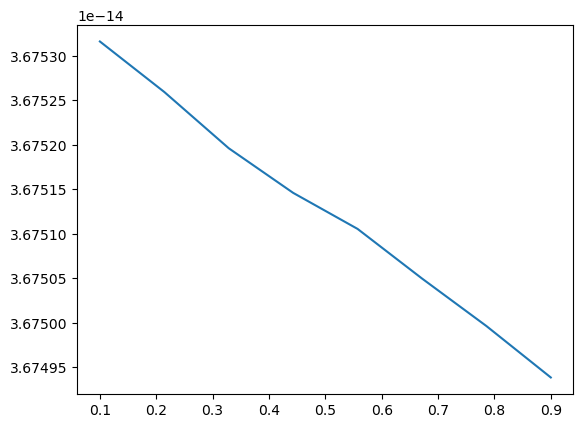

In [144]:
bi = [3]
dt = [5]

ilim = 1

fig, ax = plt.subplots()
for i in range(ilim):
    ax.plot(dk_g, intercept_md[:,bi[i]]*1e-6)
#plt.axline((0,0), (1e-12,0), color='k')
#plt.axline((0,0), (0,1e-12), color='k')
plt.show()

In [148]:
M_g = B_g*1e-6*eelib.phi0inv

In [154]:
M_g[:]/(eelib.kFAu+dk_g[0]/1e-6/2)

array([0.00189908, 0.010671  , 0.01944293, 0.02821485, 0.03698677,
       0.0457587 , 0.05453062, 0.06330255])

In [155]:
M_g[:]/(eelib.kFAu+dk_g[7]/1e-6/2)

array([0.00189901, 0.01067065, 0.01944228, 0.02821391, 0.03698554,
       0.04575717, 0.0545288 , 0.06330044])

In [ ]:
M_k = np.zeros((n_b,n_dk))
for ii in range(n_b):
    for jj in range(n_dk):
        M_k[ii,jj] = M_g[ii]/(eelib.kFAu+dk_g[jj]/1e-6/2)

M_k

array([[0.00189908, 0.00189907, 0.00189906, 0.00189905, 0.00189904,
        0.00189903, 0.00189902, 0.00189901],
       [0.010671  , 0.01067095, 0.0106709 , 0.01067085, 0.0106708 ,
        0.01067075, 0.0106707 , 0.01067065],
       [0.01944293, 0.01944283, 0.01944274, 0.01944265, 0.01944255,
        0.01944246, 0.01944237, 0.01944228],
       [0.02821485, 0.02821471, 0.02821458, 0.02821445, 0.02821431,
        0.02821418, 0.02821404, 0.02821391],
       [0.03698677, 0.0369866 , 0.03698642, 0.03698625, 0.03698607,
        0.03698589, 0.03698572, 0.03698554],
       [0.0457587 , 0.04575848, 0.04575826, 0.04575804, 0.04575783,
        0.04575761, 0.04575739, 0.04575717],
       [0.05453062, 0.05453036, 0.0545301 , 0.05452984, 0.05452958,
        0.05452932, 0.05452906, 0.0545288 ],
       [0.06330255, 0.06330225, 0.06330194, 0.06330164, 0.06330134,
        0.06330104, 0.06330074, 0.06330044]])

In [164]:
M_k**2

array([[3.60649116e-06, 3.60645681e-06, 3.60642247e-06, 3.60638812e-06,
        3.60635378e-06, 3.60631943e-06, 3.60628509e-06, 3.60625074e-06],
       [1.13870256e-04, 1.13869172e-04, 1.13868087e-04, 1.13867003e-04,
        1.13865918e-04, 1.13864834e-04, 1.13863750e-04, 1.13862665e-04],
       [3.78027333e-04, 3.78023733e-04, 3.78020133e-04, 3.78016533e-04,
        3.78012933e-04, 3.78009333e-04, 3.78005733e-04, 3.78002133e-04],
       [7.96077723e-04, 7.96070141e-04, 7.96062559e-04, 7.96054978e-04,
        7.96047397e-04, 7.96039816e-04, 7.96032235e-04, 7.96024654e-04],
       [1.36802142e-03, 1.36800840e-03, 1.36799537e-03, 1.36798234e-03,
        1.36796931e-03, 1.36795628e-03, 1.36794326e-03, 1.36793023e-03],
       [2.09385844e-03, 2.09383850e-03, 2.09381856e-03, 2.09379861e-03,
        2.09377867e-03, 2.09375873e-03, 2.09373879e-03, 2.09371885e-03],
       [2.97358876e-03, 2.97356044e-03, 2.97353213e-03, 2.97350381e-03,
        2.97347549e-03, 2.97344717e-03, 2.97341885e-03, 2.

In [178]:
slope_mM = np.zeros((4))
intercept_mM = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([M_k.T.flatten()]).T
    y = slope_md[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_mM[ii]=reg.coef_[0]
    intercept_mM[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_mM[ii], intercept_mM[ii], r2)

ii = 3

X = np.array([M_k.T.flatten()]).T
y = intercept_md[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_mM[ii]=reg.coef_[0]
intercept_mM[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_mM[ii], intercept_mM[ii], r2)


print(r)

0 -9.523875302486662e-10 1.0797810302275002e-13 0.9999405002818104
1 -9.115586309894051e-12 3.674230161486211e-08 0.02272764088589785
2 1.1985522511461173e-11 3.674325981229879e-08 0.036063591915900584
3 -1.1758373438325586e-11 3.6755324481870014e-08 0.030524784243045833
0.02272764088589785


M fitting doesn't help, except for the linear imag term. These terms seem to help get the main signal closer to a uniform slope (if considered necessary), but for the quartic terms, there is no point. I want to see if I can just ignore this fitting for other terms in the model.

In [179]:
X = np.array([M_k.T.flatten()]).T
y = slope_md[:,:,0].flatten()

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mMi=reg.coef_[0]
intercept_mMi=reg.intercept_

r2 = reg.score(X, y)

print(slope_mMi*1e-6*0.05, r2)

-4.749937809412196e-17 0.9999317369996303


In [182]:
intercept_mM = np.zeros((3))
r = 1.1    # for finding the minimum r value


for ii in range(1,3):
    intercept_mM[ii-1]=np.average(slope_md[:,:,ii])

    print(intercept_mM[ii-1]*1e-6)

ii = 2

intercept_mM[ii]=np.average(intercept_md[:,:])

print(intercept_mM[ii]*1e-6)

3.674200444430406e-14
3.674365054354659e-14
3.6754941155742904e-14


Quartic terms appear unnecessary here. Lets go back to the $k$ dependence.

In [183]:
k_arr = np.zeros((n_dk, n_b))
for ii in range(n_dk):
    for jj in range(n_b):
        k_arr[ii,jj]=dk_g[ii]

In [184]:
k_arr = k_arr.flatten()

In [200]:
slope_mk = np.zeros((4,2))
intercept_mk = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([k_arr, k_arr**2]).T
    y = slope_md[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_mk[ii]=reg.coef_
    intercept_mk[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_mk[ii]*1e-6, intercept_mk[ii]*1e-6, r2)

ii = 3

X = np.array([k_arr, k_arr**2]).T
y = intercept_md.flatten()

reg = LinearRegression().fit(X, y)

slope_mk[ii]=reg.coef_
intercept_mk[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_mk[ii]*1e-6, intercept_mk[ii]*1e-6, r2)


print(r)

0 [ 6.14176827e-20 -6.57390684e-20] -3.0949877018904074e-17 4.57465424430481e-08
1 [-3.83686784e-18 -6.53954363e-19] 3.6744131209402115e-14 0.937403043250955
2 [-5.16664202e-18  4.96262484e-19] 3.674607576950877e-14 0.9300881472904924
3 [-5.01963765e-18  3.58580208e-19] 3.675733674116089e-14 0.8144602631425454
4.57465424430481e-08


There is little evidence of any dependence. Everything is within error. Ok. Lets put together this mess.

In [201]:
consts = {}

In [202]:
consts["mA2"] = intercept_mM[2]
consts["mDIM"] = slope_mMi
consts["mDI2"] = intercept_mM[0]
consts["mDR2"] = intercept_mM[1]

In [203]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08}

So far, first correction has 3 terms, and the second correction has one so far. The first correction is a reasonably simple model here, with one fitted parameter. The parameters only split around the point of my second correction. The second correction will be frustrating, however, and I don't know which terms are error. The $\mu$ intercept terms are definitely error. I will need to compare these to the numerical model without ee interaction.

# $k$ and $M$ Regression for $\mu^2$ Term

In [213]:
np.shape(slope_m2d)

(8, 8, 5)

Like before.

**k dependency terms**

In [215]:
slope_m2k = np.zeros((6,n_b,2))
intercept_m2k = np.zeros((6,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(5):
    for jj in range(n_b):
        X = np.array([np.power(dk_g,1), np.power(dk_g,2)]).T
        y = slope_m2d[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_m2k[ii,jj]=reg.coef_
        intercept_m2k[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_m2k[ii,jj]*1e-10, intercept_m2k[ii,jj]*1e-10, r2)

ii = 5

for jj in range(n_b):
    X = np.array([np.power(dk_g,1), np.power(dk_g,2)]).T
    y = intercept_m2d[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_m2k[ii,jj]=reg.coef_
    intercept_m2k[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_m2k[ii,jj]*1e-10, intercept_m2k[ii,jj]*1e-10, r2)


print(r)

0 0 [-4.97996421e-17  2.24301983e-17] 2.0955154027310095e-15 0.6536039094575625
0 1 [ 2.80469691e-18 -5.40151144e-18] 2.051605739737058e-15 0.0938648664119458
0 2 [-1.31803468e-17  1.06114966e-17] 2.072782573185859e-15 0.19410759156219792
0 3 [-2.5889114e-17  2.0313896e-17] 2.0807873064796886e-15 0.3398702825538693
0 4 [ 5.49412023e-19 -1.11231873e-17] 2.02984605928466e-15 0.8157369846938615
0 5 [-4.15140990e-18  6.30358811e-18] 2.0411433506012414e-15 0.7118758475735738
0 6 [ 3.10548639e-18 -6.20268053e-18] 2.0543859261560344e-15 0.6587598297892493
0 7 [-4.92170697e-17  4.06165489e-17] 2.062009754041156e-15 0.8222713619657356
1 0 [ 5.59836380e-17 -4.54991101e-17] 2.955052886265664e-15 0.799491539736805
1 1 [ 1.59342222e-17 -9.01200540e-18] 2.9386904000764252e-15 0.6458169379913377
1 2 [ 7.37230593e-18 -1.51799949e-17] 2.9743105941802724e-15 0.7564172088362724
1 3 [5.73032753e-18 1.51735676e-18] 2.9407290134716066e-15 0.8426005702217423
1 4 [-1.39309211e-17  1.34228758e-17] 2.9082347644

Nothing at our order, poor convergence, ... In theory I could claim something existed, but it seems unnecessary.

In [218]:
slope_m2M = np.zeros((6,2))
intercept_m2M = np.zeros((6))
r = 1.1    # for finding the minimum r value


for ii in range(5):
    X = np.array([M_k.T.flatten(), M_k.T.flatten()**2]).T
    y = slope_m2d[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_m2M[ii]=reg.coef_[0]
    intercept_m2M[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_m2M[ii]*1e-10*0.06, intercept_m2M[ii]*1e-10, r2)

ii = 5

X = np.array([M_k.T.flatten()]).T
y = intercept_m2d[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_m2M[ii]=reg.coef_[0]
intercept_m2M[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_m2M[ii]*1e-10*0.06, intercept_m2M[ii]*1e-10, r2)


print(r)

0 [-7.54936033e-17 -7.54936033e-17] 2.077844534341095e-15 0.32731945012420627
1 [-5.57809655e-17 -5.57809655e-17] 2.968487913445464e-15 0.6727795684037625
2 [3.86383798e-17 3.86383798e-17] 1.5829064017782416e-15 0.5647254392767549
3 [5.26301449e-17 5.26301449e-17] 1.5785468639316267e-15 0.4597033195434912
4 [-9.27278173e-18 -9.27278173e-18] 3.1808532960777826e-15 0.2616124065862706
5 [3.2511521e-17 3.2511521e-17] 8.345576199757135e-16 0.5596244300451372
0.2616124065862706


Nothing. 

In [221]:
ave_c_m2d = np.zeros((6))
for i in range(5):
    ave_c_m2d[i] = np.average(slope_m2d[:,:,i])
ave_c_m2d[5] = np.average(intercept_m2d)
print(ave_c_m2d*1e-10)

[2.05561148e-15 2.93585975e-15 1.59820712e-15 1.59105779e-15
 3.18235870e-15 8.52222358e-16]


These are only relevant for the largest $\mu$ values, which are likely unimportant. I will save them anyway.

In [222]:
consts["m2"] = ave_c_m2d[5]
consts["m2DI2"] = ave_c_m2d[0]
consts["m2DR2"] = ave_c_m2d[1]
consts["m2DR4"] = ave_c_m2d[2]
consts["m2DI4"] = ave_c_m2d[3]
consts["m2DI2R2"] = ave_c_m2d[4]

In [223]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05}

# $k$ and $M$ Regression for $\mu$ Intercept Term

In [225]:
slope_m0k = np.zeros((4,n_b,2))
intercept_m0k = np.zeros((4,n_b))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    for jj in range(n_b):
        X = np.array([np.sin(pi*dk_g), np.cos(pi*dk_g)]).T
        y = slope_m0d[:,jj,ii]

        reg = LinearRegression().fit(X, y)

        slope_m0k[ii,jj]=reg.coef_
        intercept_m0k[ii,jj]=reg.intercept_

        r2 = reg.score(X, y)
        r = min(r, r2)

        print(ii, jj, slope_m0k[ii,jj], intercept_m0k[ii,jj], r2)

ii = 3

for jj in range(n_b):
    X = np.array([np.sin(pi*dk_g), np.cos(pi*dk_g)]).T
    y = intercept_m0d[:,jj]

    reg = LinearRegression().fit(X, y)

    slope_m0k[ii,jj]=reg.coef_
    intercept_m0k[ii,jj]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, jj, slope_m0k[ii,jj], intercept_m0k[ii,jj], r2)


print(r)

0 0 [-1.75157013e-18  5.90869215e-19] -2.757122527641111e-16 0.6810883966910385
0 1 [-1.14451282e-18 -3.09946952e-20] -2.7475665086031333e-16 0.3569503203165908
0 2 [-1.39000980e-18 -6.13896064e-19] -2.737129149998444e-16 0.3828245942765759
0 3 [-2.00127428e-18 -2.41661820e-19] -2.7522578237656255e-16 0.7540739651986659
0 4 [5.55825229e-19 4.13226292e-19] -2.7888480457149374e-16 0.7487652850333633
0 5 [-4.45663652e-19  1.17545496e-19] -2.76472865382808e-16 0.16292070036167594
0 6 [1.30439534e-18 2.84534795e-19] -2.765885279487947e-16 0.8352064590920366
0 7 [-4.30345399e-19 -3.69897931e-19] -2.744282009810987e-16 0.8719342017977375
1 0 [ 2.44634972e-19 -4.58040316e-20] 8.041514825047796e-17 0.42563347265454987
1 1 [7.58183440e-20 9.59226065e-20] 8.067433829173884e-17 0.806361544241831
1 2 [3.28147942e-19 5.77134205e-20] 8.104829947468711e-17 0.4420869865032089
1 3 [4.70257470e-19 5.70176003e-20] 8.070204815706324e-17 0.8721887717442938
1 4 [-1.07219077e-19 -1.01864257e-19] 8.15560332241

Nothing.

In [227]:
slope_m0M = np.zeros((4,2))
intercept_m0M = np.zeros((4))
r = 1.1    # for finding the minimum r value


for ii in range(3):
    X = np.array([M_k.T.flatten(), M_k.T.flatten()**2]).T
    y = slope_m0d[:,:,ii].flatten()

    reg = LinearRegression().fit(X, y)

    slope_m0M[ii]=reg.coef_[0]
    intercept_m0M[ii]=reg.intercept_

    r2 = reg.score(X, y)
    r = min(r, r2)

    print(ii, slope_m0M[ii]*0.06, intercept_m2M[ii], r2)

ii = 3

X = np.array([M_k.T.flatten()]).T
y = intercept_m0d[:,:].flatten()

reg = LinearRegression().fit(X, y)

slope_m0M[ii]=reg.coef_[0]
intercept_m0M[ii]=reg.intercept_

r2 = reg.score(X, y)
r = min(r, r2)

print(ii, slope_m0M[ii]*0.06, intercept_m0M[ii], r2)


print(r)

0 [-4.65201631e-18 -4.65201631e-18] 2.077844534341095e-05 0.14345076580073834
1 [3.18608464e-18 3.18608464e-18] 2.9684879134454636e-05 0.7400688929470078
2 [5.5400165e-18 5.5400165e-18] 1.5829064017782415e-05 0.38115356006574186
3 [-6.20169984e-20 -6.20169984e-20] -5.697027686587538e-16 0.001614295292520218
0.001614295292520218


Nothing again.

        X = np.array([np.imag(dgridk[ii].flatten())**2, np.real(dgridk[ii].flatten())**2, np.imag(dgridk[ii].flatten())**4]).T


In [228]:
consts["intercept"] = np.average(intercept_m0d)
consts["DI2"] = np.average(slope_m0d[:,:,0])
consts["DR2"] = np.average(slope_m0d[:,:,1])
consts["DI4"] = np.average(slope_m0d[:,:,2])

In [229]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17}

Ok. Now to test the model. (And compare to the old model from the other grid.)

# Model Testing

In [237]:
np.shape(dgridk)

(8, 15, 15)

In [286]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17,
 'mBDI': 8.881913496260701e-10}

In [232]:
dgrid_n = dgrid * t_new / eelib.pi

In [251]:
t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    #t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                    #                         + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                    #                         + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

                    # mu linear terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]*(consts['mDR2'] * np.real(dgridk[kk,ii,jj])**2
                                                      + consts['mDI2'] * np.imag(dgridk[kk,ii,jj])**2
                                                      + consts['mA2'])
                                                      #+ consts['mDIM'] * np.imag(dgridk[kk,ii,jj]) * B_g[nn])

                    # mu quadradic terms
                    #t_pred[mm,kk,nn,ii,jj] += mu_g[nn]**2*(consts['m2']
                    #        + consts['m2DI2'] * np.imag(dgridk[kk,ii,jj])**2
                    #        + consts['m2DR2'] * np.real(dgridk[kk,ii,jj])**2 
                    #        + consts['m2DR4'] * np.real(dgridk[kk,ii,jj])**4 
                    #        + consts['m2DI4'] * np.imag(dgridk[kk,ii,jj])**4
                    #        + consts['m2DI2R2'] * np.real(dgridk[kk,ii,jj])**2 * np.imag(dgridk[kk,ii,jj])**2)
                    

In [252]:
np.max(fot-t_pred), np.min(fot-t_pred)

(3.4409606539649355e-14, -2.2994415196096463e-16)

In [301]:
t_pred = np.zeros((n_m, n_dk, n_b, n_g, n_g))

for mm in range(n_m): 
    for kk in range(n_dk):
        for nn in range (n_b):
            for ii in range(n_g):
                for jj in range(n_g):
                    # constant terms -- t_0 and intercept (error)
                    t_pred[mm,kk,nn,ii,jj] = pi /(eelib.kFAu+dk_g[kk]/1e-6/2.0) + consts['intercept']
                    # terms independent of mu (error)
                    t_pred[mm,kk,nn,ii,jj] += (np.real(dgridk[kk,ii,jj])**2 * consts['DR2'] 
                                             + np.imag(dgridk[kk,ii,jj])**2 * consts['DI2'] 
                                             + np.imag(dgridk[kk,ii,jj])**4 * consts['DI4'])

                    # mu linear terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]*(consts['mDR2'] * np.real(dgridk[kk,ii,jj])**2
                                                      + consts['mDI2'] * np.imag(dgridk[kk,ii,jj])**2
                                                      + consts['mA2']
                                                      + consts['mDIM'] * np.imag(dgridk[kk,ii,jj]) * B_g[nn])

                    # mu quadradic terms
                    t_pred[mm,kk,nn,ii,jj] += mu_g[mm]**2*(consts['m2']
                            + consts['m2DI2'] * np.imag(dgridk[kk,ii,jj])**2
                            + consts['m2DR2'] * np.real(dgridk[kk,ii,jj])**2 
                            + consts['m2DR4'] * np.real(dgridk[kk,ii,jj])**4 
                            + consts['m2DI4'] * np.imag(dgridk[kk,ii,jj])**4
                            + consts['m2DI2R2'] * np.real(dgridk[kk,ii,jj])**2 * np.imag(dgridk[kk,ii,jj])**2)

In [302]:
np.max(fot-t_pred), np.min(fot-t_pred)

(1.3048743241978739e-16, -1.6540096097562107e-16)

In [261]:
mu_g

array([1.00000000e-08, 2.68269580e-08, 7.19685673e-08, 1.93069773e-07,
       5.17947468e-07, 1.38949549e-06, 3.72759372e-06, 1.00000000e-05])

In [293]:
size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_b*n_g**2, n_b*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_b):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-t_pred[imu, ik, ib, idr, idi]

115200


In [294]:
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T fast"])

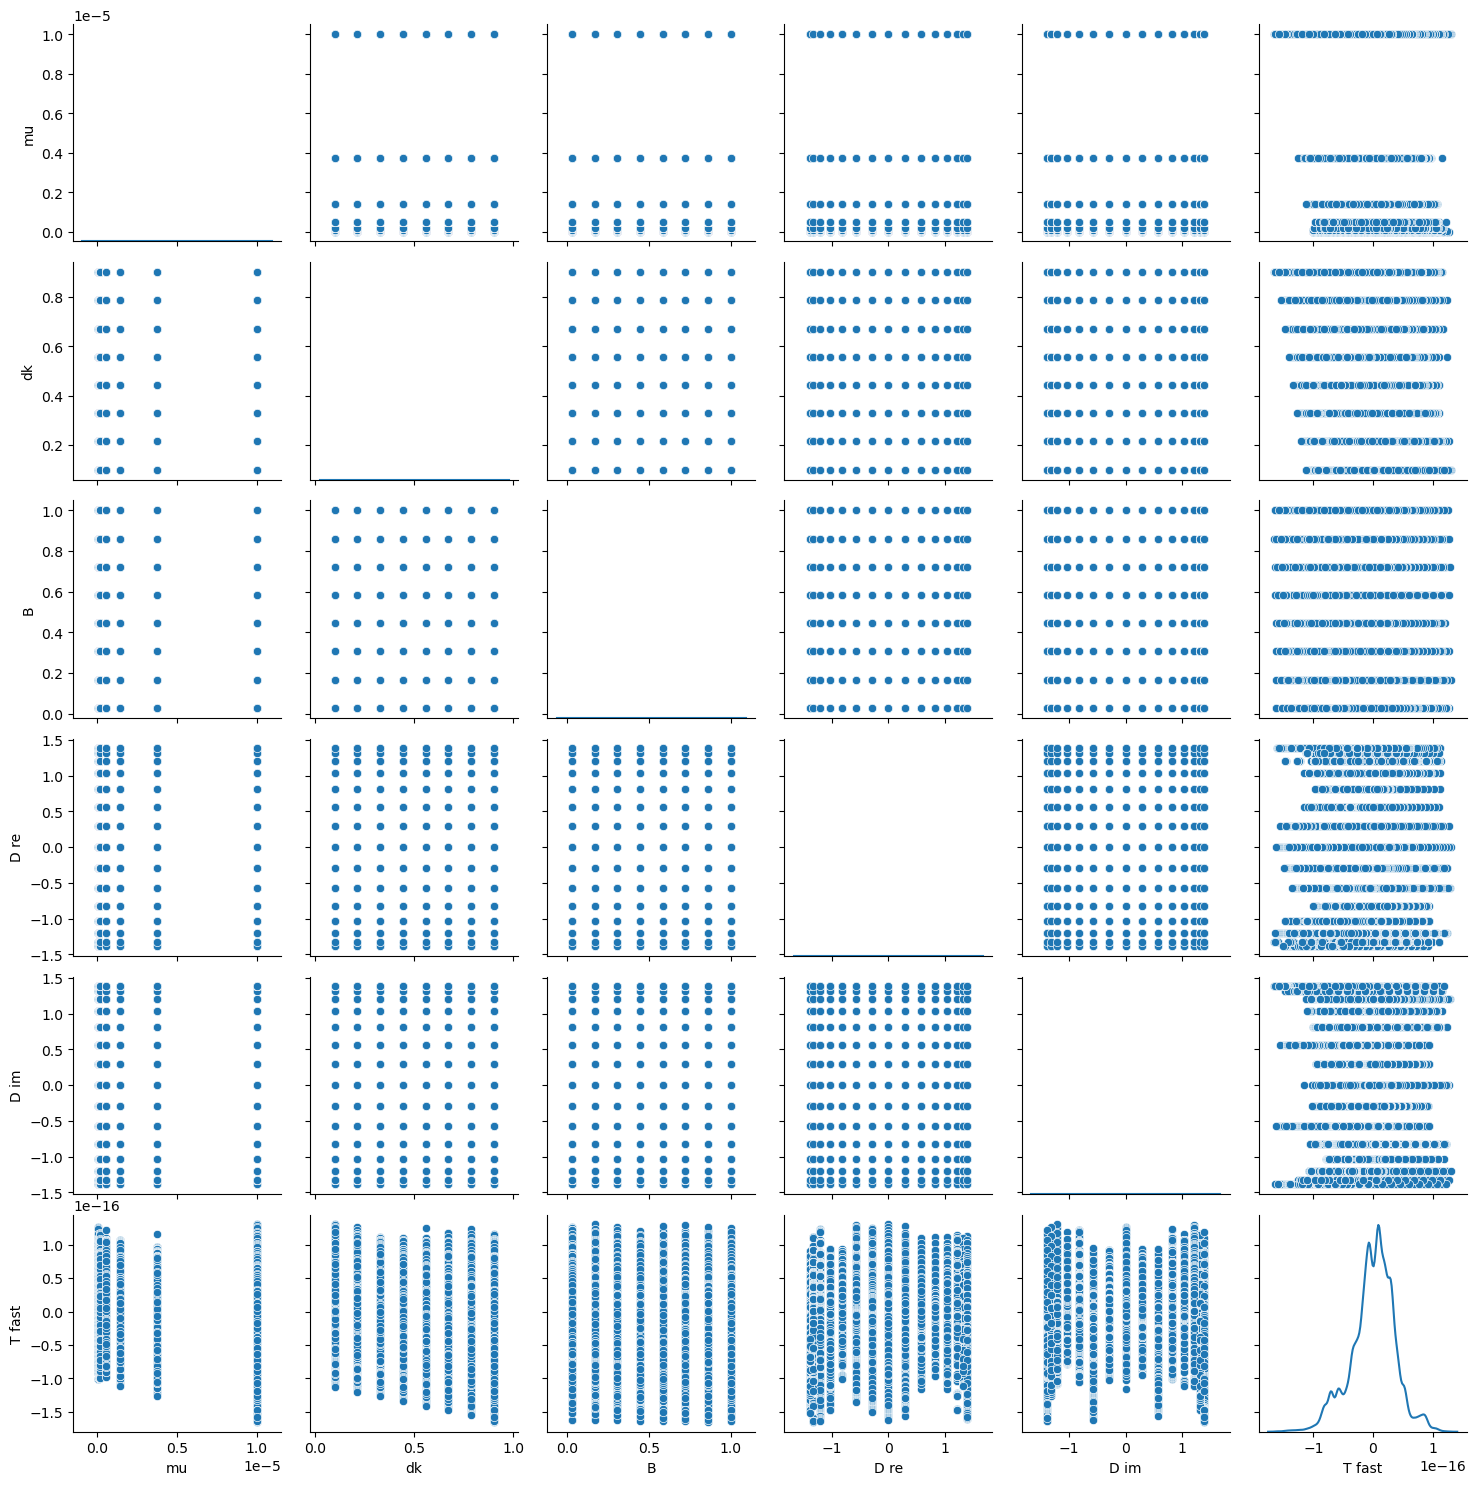

In [295]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

There are signals here, but I hope that we are already within tolerance. Linear, quadratic, and quartic terms are visible. Taylor expansion approximations work great here. 

# $\mu B \Im(\Psi^\prime_0)$ term

In [273]:
dfa.head()

,mu,dk,B,D re,D im,T fast
0,1.000000e-08,0.1,0.03,-1.380810,-1.38081,6.118232e-19
1,1.000000e-08,0.1,0.03,-1.321546,-1.38081,-7.102350e-18
2,1.000000e-08,0.1,0.03,-1.204153,-1.38081,-6.854996e-17
3,1.000000e-08,0.1,0.03,-1.033794,-1.38081,-3.989327e-17
4,1.000000e-08,0.1,0.03,-0.817964,-1.38081,-4.591820e-17


In [275]:
X = np.array([npaf[:,0]*npaf[:,2]*npaf[:,4]]).T

y = npaf[:,5]

reg = LinearRegression(fit_intercept=False).fit(X, y)

slope_mbi=reg.coef_
intercept_mbi=reg.intercept_

r = reg.score(X, y)

print(slope_mbi, intercept_mbi, r)
    

[8.8819135e-10] 0.0 0.9996664454493913


In [277]:
npaf[:,5] = npaf[:,5]-npaf[:,0]*npaf[:,2]*npaf[:,4]*slope_mbi

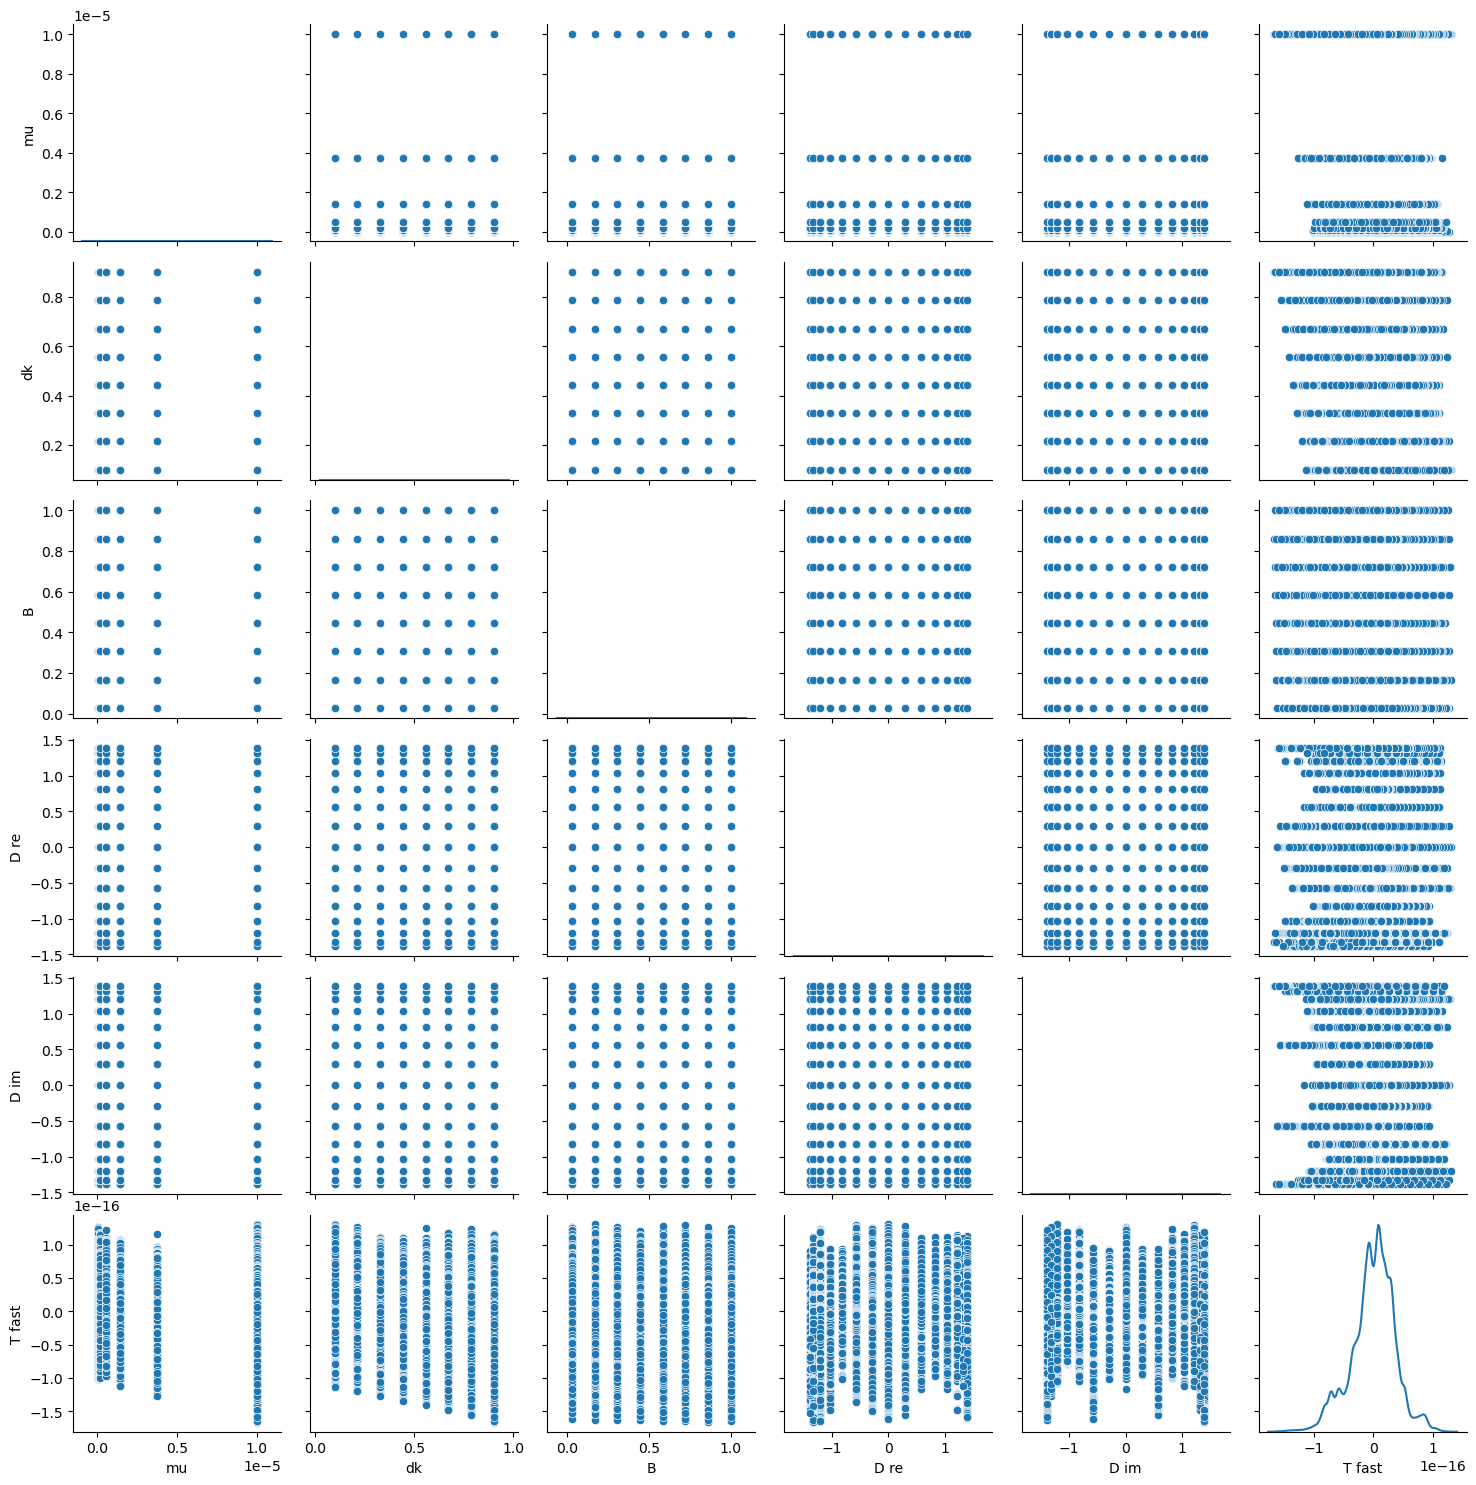

In [278]:
g = sns.PairGrid(dfa)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)

In [279]:
np.max(npaf[:,5]), np.min(npaf[:,5])

(1.3049494444295748e-16, -1.6579712425870837e-16)

Works well. Now I need to test this on other data. 

In [283]:
consts["mBDI"] = slope_mbi[0]

In [284]:
consts

{'mA2': 3.675494115574291e-08,
 'mDIM': -9.499875618824391e-10,
 'mDI2': 3.674200444430406e-08,
 'mDR2': 3.674365054354659e-08,
 'm2': 8.522223583430349e-06,
 'm2DI2': 2.0556114758548036e-05,
 'm2DR2': 2.9358597545134476e-05,
 'm2DR4': 1.598207117609667e-05,
 'm2DI4': 1.5910577914323505e-05,
 'm2DI2R2': 3.182358695140475e-05,
 'intercept': -5.697364648383741e-16,
 'DI2': -2.7618261397447087e-16,
 'DR2': 8.0960114314636e-17,
 'DI4': 9.19298181818588e-17,
 'mBDI': 8.881913496260701e-10}

In [300]:
import json

# writing dictionary to a file as JSON
with open('consts.json', 'w') as f:
    json.dump(consts, f)

I have a mBDI term already. It must not be correct. I may have tried to scale it by $R$, but now I think that the term is better, and I can deal with adding $R$ scaling later.
... No. It is just not correct. Wrong sign, same absolute value. Sign errors are understandable if I subtracted rather than added. 

I can do better by adding $k_0$ to the variables to vary, and testing if this model still works. I think I want Monte Carlo for testing, not the grid.

Remember -- on future runs -- $R$ and $k_0$ are here held constant. Adjust based on new values. I know where $R$ and $k_0$ appear in my model, in principle.

In [296]:
consts['mDIM']= consts['mDIM'] + consts['mBDI']

In [297]:
consts['mBDI'] = 0

# Old Model